<div style="background: white; height: 100px; display: flex; justify-content: center; align-items: center;">
    <div style="text-align: center;">
        <h3 style="color: purple; font-weight: bold; margin: 0;"> Name: RA Dayou </h3>
        <h3 style="color: purple; font-weight: bold; margin: 0;"> ID: e2023052 </h3>
    </div>
</div>

Remarks: All models here should be built from scratch.

In [179]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

### Logistic regression

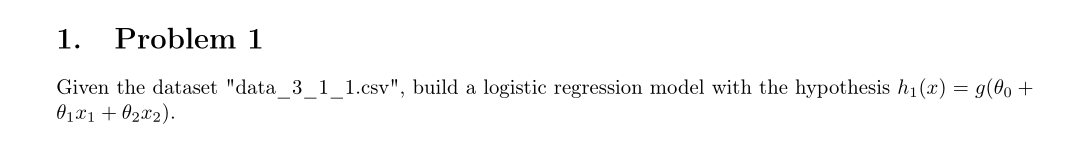

In [180]:
df1 = pd.read_csv("data_3_1_1 (2).csv")
df1.head()

,x1,x2,class
0,6.70,6.79,1
1,6.92,3.87,1
2,7.87,5.36,1
3,2.93,6.91,0
4,6.67,4.92,1


In [181]:
X = df1[['x1', 'x2']].values
y = df1['class'].values

In [182]:
# z 
def hypothesis(X: np.ndarray, theta: np.ndarray, bias):
    return X @ theta.T + bias

# sigmoid function
def sigmoid(X, theta, bias):
    return 1 / (1 + np.exp(-hypothesis(X, theta, bias)))

# optimize using gradient descent
def gradient_descent(X, y_real, learning_rate, epochs):
    m = len(X)
    thetas = np.zeros(X.shape[1])
    bias = 0

    for i in range(epochs):
        y_pred = sigmoid(X, thetas, bias)
        error = y_pred - y_real

        d_theta = (1/m) * (X.T @ error)
        d_bias = np.mean(error)

        thetas -= learning_rate * d_theta
        bias -= learning_rate * d_bias

    return thetas, bias

# Dicision boundary
def decision(X, thetas, bias):
    probs = sigmoid(X, thetas, bias)
    return (probs >= 0.5).astype(int)

# Test model
def model_accuracy(X_test, y_real, thetas, bias):
    m = len(X_test)
    y_pred = decision(X_test, thetas, bias)
    tp, fp, fn = 0, 0, 0
    for pred, real in zip(y_pred, y_real):
        if pred == real:
            tp += 1 if pred == 1 else 0
        else:
            fp += 1 if pred == 1 else 0
            fn += 1 if pred == 0 else 0

    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return precision, recall, f1_score

# Split data to 80, 20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

thetas, bias = gradient_descent(X_train, y_train, learning_rate=0.01, epochs=1000)
precision, recall, f1_score = model_accuracy(X_test, y_test, thetas, bias)

print(f"{"="*20}")
print(f"Weights: ", thetas)
print(f"Bias: ", bias)
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1_score: {f1_score}")

print(f"{"="*20}")
y_pred = decision(X_test, thetas, bias)
print("Predict\t\tActual")
for i, j in zip(y_pred, y_test):
    print(f"{i}\t\t{j}")
print(f"{"="*20}")

Weights:  [ 1.34190443 -1.09313665]
Bias:  -0.07214824154153816
Precision: 1.0
Recall: 0.9
F1_score: 0.9473684210526316
Predict		Actual
0		0
0		0
0		0
0		0
0		0
0		1
1		1
1		1
1		1
1		1
0		0
1		1
1		1
0		0
0		0
1		1
1		1
0		0
0		0
1		1


In [ ]:
# Decision boundary line
x1 = np.linspace(X[:, 0].min() - 0.5, X[:, 0] + .5, len(X))
x1_norm = (X[0] - X[0].mean()) / X[0].std()
x2_norm = 

# Scatter plots
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0, 0], X[y == 0, 1], c='tab:blue',   label='Class 0', s=20)
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='tab:orange', label='Class 1', s=20)

# Boundary line
# plt.plot(X[:, 0], X[:, 1], c='red', linewidth=2, label='Decision Boundary')

plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Logistic Regression')
plt.legend()
plt.show()

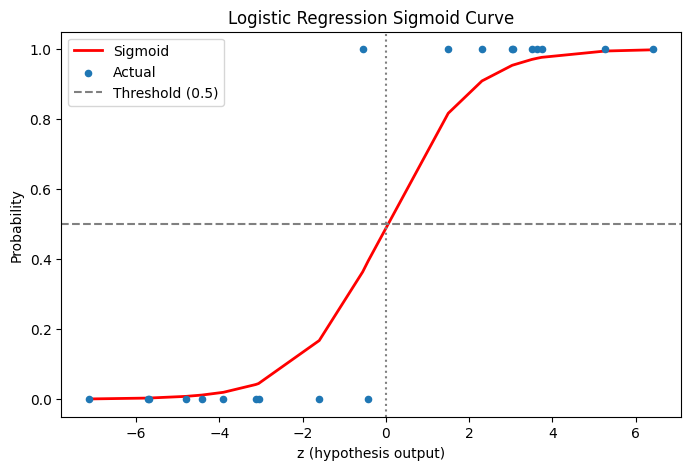

In [183]:
# Get hypothesis values and sort them for a smooth curve
z = hypothesis(X_test, thetas, bias)
z_sorted = np.sort(z)
sigmoid_vals = 1 / (1 + np.exp(-z_sorted))

plt.figure(figsize=(8, 5))

# Plot sigmoid curve
plt.plot(z_sorted, sigmoid_vals, c='red', label='Sigmoid', linewidth=2)

# Plot actual points
plt.scatter(z, y_test, c='tab:blue', label='Actual', s=20, zorder=3)

# Threshold line
plt.axhline(y=0.5, color='gray', linestyle='--', label='Threshold (0.5)')
plt.axvline(x=0, color='gray', linestyle=':')

plt.xlabel('z (hypothesis output)')
plt.ylabel('Probability')
plt.title('Logistic Regression Sigmoid Curve')
plt.legend()
plt.show()

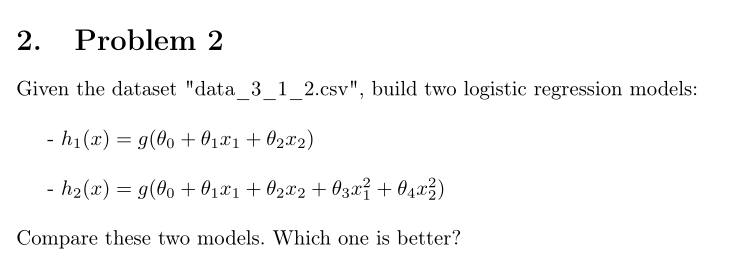

First One

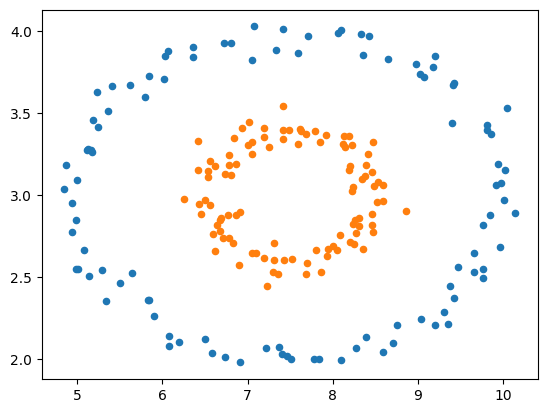

In [184]:
df2 = pd.read_csv("data_3_1_2.csv")

X = df2[['x1', 'x2']].values
y = df2['class'].values

plt.scatter(X[y == 0, 0], X[y == 0, 1], c='tab:blue', label='Class 0', s = 20)
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='tab:orange', label='Class 1', s = 20)

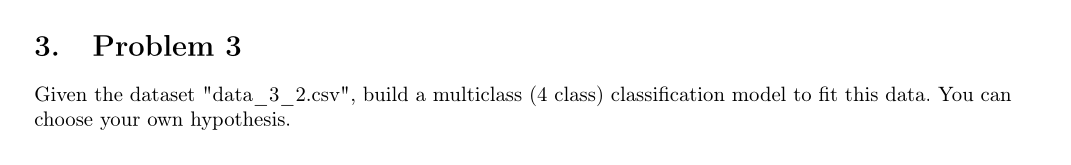

In [185]:
df3 = pd.read_csv("data_3_2.csv")

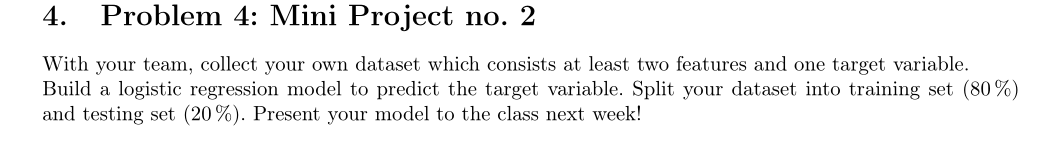